In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# Load Dataset
df = pd.read_csv('startup.csv')
df.head()

,RD_Spend,Administration,Marketing_Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
# Data Cleaning
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Drop duplicates if any
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

# Check data types
print("\nData Types:\n", df.dtypes)

# Reset index after cleaning
df = df.reset_index(drop=True)
print("\nData is Clean and Ready!")

Missing Values:
 RD_Spend           0
Administration     0
Marketing_Spend    0
State              0
Profit             0
dtype: int64

Shape after removing duplicates: (50, 5)

Data Types:
 RD_Spend           float64
Administration     float64
Marketing_Spend    float64
State                  str
Profit             float64
dtype: object

Data is Clean and Ready!


In [5]:
# Encoding to convert State column from categorical to numerical
# One Hot Encoding for State column
df = pd.get_dummies(df, columns=['State'], drop_first=True)

print("Columns after Encoding:\n", df.columns.tolist())
print("\nNew Shape:", df.shape)
df.head()

Columns after Encoding:
 ['RD_Spend', 'Administration', 'Marketing_Spend', 'Profit', 'State_Florida', 'State_New York']

New Shape: (50, 6)


,RD_Spend,Administration,Marketing_Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [7]:
# Split X and Y 
# X = input features, Y = target output
X = df.drop('Profit', axis=1)
Y = df['Profit']

In [8]:
# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training size:", len(X_train), "rows")
print("Testing size:", len(X_test), "rows")

Training size: 40 rows
Testing size: 10 rows


In [10]:
# Build & Train Regression Model
# Build the model
model = LinearRegression()

# Train the model
model.fit(X_train, Y_train)

print("Model Trained Successfully!")
print("\nIntercept:", model.intercept_)
print("\nCoefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"  {col}: {coef:.4f}")

Model Trained Successfully!

Intercept: 54028.03959364583

Coefficients:
  RD_Spend: 0.8056
  Administration: -0.0688
  Marketing_Spend: 0.0299
  State_Florida: 938.7930
  State_New York: 6.9878


In [11]:
# Predict and Checking Accuracy
# Predict on test data
Y_pred = model.predict(X_test)

# Compare Actual vs Predicted
comparison = pd.DataFrame({'Actual Profit': Y_test.values, 'Predicted Profit': Y_pred})
print(comparison)

# Accuracy Metrics
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

print("\n Model Accuracy")
print(f"R² Score:  {r2:.3f}")
print(f"MSE:       {mse:.3f}")
print(f"RMSE:      {rmse:.3f}")

   Actual Profit  Predicted Profit
0      134307.35     126362.879083
1       81005.76      84608.453836
2       99937.59      99677.494251
3       64926.08      46357.460686
4      125370.37     128750.482885
5       35673.41      50912.417419
6      105733.54     109741.350327
7      107404.34     100643.242816
8       97427.84      97599.275746
9      122776.86     113097.425244

 Model Accuracy
R² Score:  0.899
MSE:       82010363.044
RMSE:      9055.957


In [12]:
# Predict new values
# New input data from your assignment
new_data = pd.DataFrame({
    'RD_Spend':         [21892.92, 23940.93],
    'Administration':   [81910.77, 96489.63],
    'Marketing_Spend':  [164270.70, 137001.10],
    'State_Florida':    [False, False],
    'State_New York':   [False, False]})

# Predict
new_pred = model.predict(new_data)

print("\n Predicted Profits")
print(f"Startup 1 Profit: ₹ {new_pred[0]:,.2f}")
print(f"Startup 2 Profit: ₹ {new_pred[1]:,.2f}")


 Predicted Profits
Startup 1 Profit: ₹ 70,935.54
Startup 2 Profit: ₹ 70,768.48


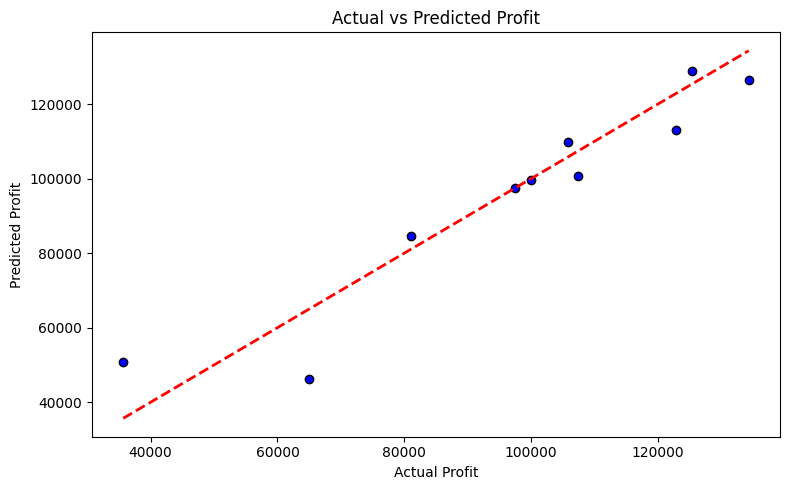

In [13]:
# Visualizations
plt.figure(figsize=(8,5))
plt.scatter(Y_test, Y_pred, color='blue', edgecolors='black')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit')
plt.tight_layout()
plt.show()

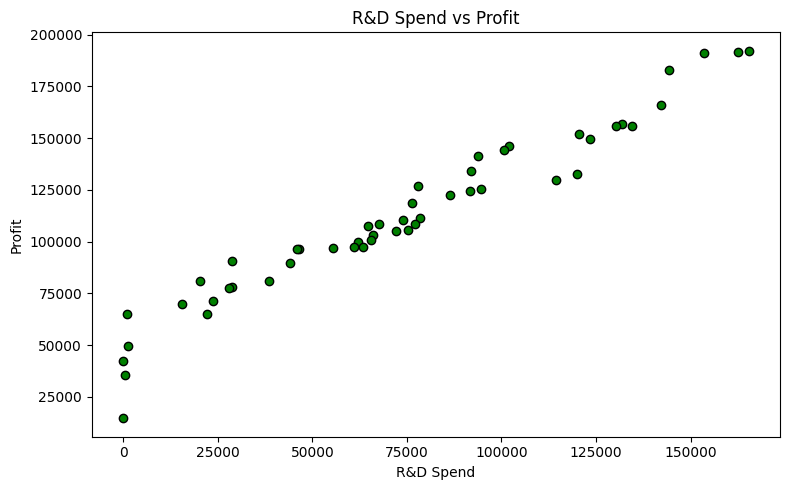

In [14]:
# R&D Vs Profit
plt.figure(figsize=(8,5))
plt.scatter(df['RD_Spend'], df['Profit'], color='green', edgecolors='black')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.title('R&D Spend vs Profit')
plt.tight_layout()
plt.show()

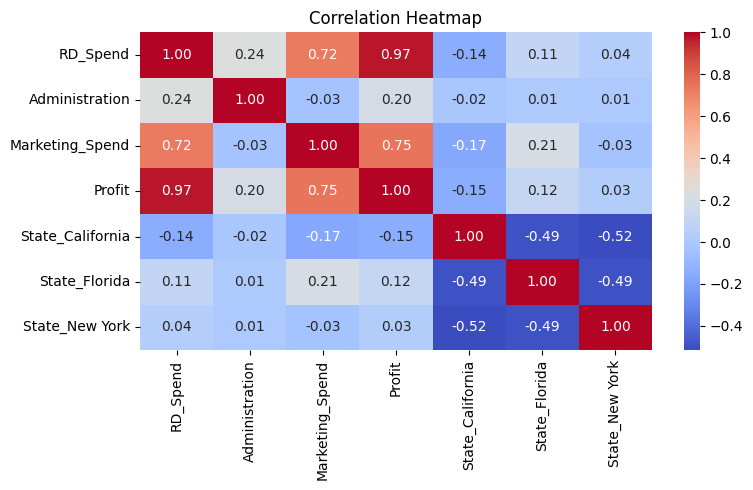

In [22]:
# Correlation Heatmap
# Reload original data
df_viz = pd.read_csv('startup.csv')

# Create dummies WITHOUT drop_first
df_corr = pd.get_dummies(df_viz, columns=['State'], drop_first=False)

# Convert bool to int
df_corr['State_California'] = df_corr['State_California'].astype(int)
df_corr['State_Florida'] = df_corr['State_Florida'].astype(int)
df_corr['State_New York'] = df_corr['State_New York'].astype(int)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11788\3175395728.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='State', y='Profit', data=df_viz, palette='Set2')


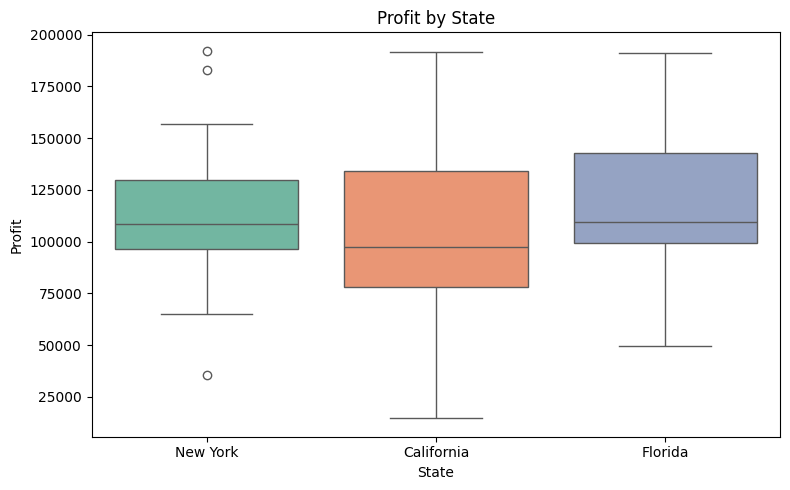

In [19]:
# Profit Distribution
# Add State column back for visualization purpose only
df_viz = pd.read_csv('startup.csv')  # reload original data with State column

# Plot Profit by State
plt.figure(figsize=(8,5))
sns.boxplot(x='State', y='Profit', data=df_viz, palette='Set2')
plt.title('Profit by State')
plt.tight_layout()
plt.show()

In [24]:
# Summary
print("=" * 50)
print("       STARTUP PROFIT REGRESSION ANALYSIS")
print("=" * 50)

print(f"\nDataset     : 50 Startups")
print(f"States      : California, Florida, New York")
print(f"Target      : Profit Prediction")
print(f"Model       : Multiple Linear Regression")

print("\n--- Model Performance ---")
print(f"R² Score  : {r2:.4f}  → Model is {r2*100:.2f}% accurate")
print(f"RMSE      : {rmse:.4f} → Avg error of ₹{rmse:,.2f}")

print("\n--- Feature Impact on Profit ---")
for col, coef in zip(X.columns, model.coef_):
    impact = "↑ Increases" if coef > 0 else "↓ Decreases"
    print(f"  {col:25s}: {impact} Profit by ₹{abs(coef):.4f} per ₹1 spent")

print("\n--- New Predictions ---")
print(f"  Startup 1 Predicted Profit : ₹ {new_pred[0]:,.2f}")
print(f"  Startup 2 Predicted Profit : ₹ {new_pred[1]:,.2f}")


       STARTUP PROFIT REGRESSION ANALYSIS

Dataset     : 50 Startups
States      : California, Florida, New York
Target      : Profit Prediction
Model       : Multiple Linear Regression

--- Model Performance ---
R² Score  : 0.8987  → Model is 89.87% accurate
RMSE      : 9055.9573 → Avg error of ₹9,055.96

--- Feature Impact on Profit ---
  RD_Spend                 : ↑ Increases Profit by ₹0.8056 per ₹1 spent
  Administration           : ↓ Decreases Profit by ₹0.0688 per ₹1 spent
  Marketing_Spend          : ↑ Increases Profit by ₹0.0299 per ₹1 spent
  State_Florida            : ↑ Increases Profit by ₹938.7930 per ₹1 spent
  State_New York           : ↑ Increases Profit by ₹6.9878 per ₹1 spent

--- New Predictions ---
  Startup 1 Predicted Profit : ₹ 70,935.54
  Startup 2 Predicted Profit : ₹ 70,768.48
